<a href="https://colab.research.google.com/github/sathvika12-8/Python_learning/blob/main/EDA%26Outliers_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the csv in pandas dataframe and plot histograms for height and weight parameters
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("Uploaded file:",file_name)

Saving weight-height.csv to weight-height.csv
Uploaded file: weight-height.csv


In [ ]:
df = pd.read_csv(file_name)
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


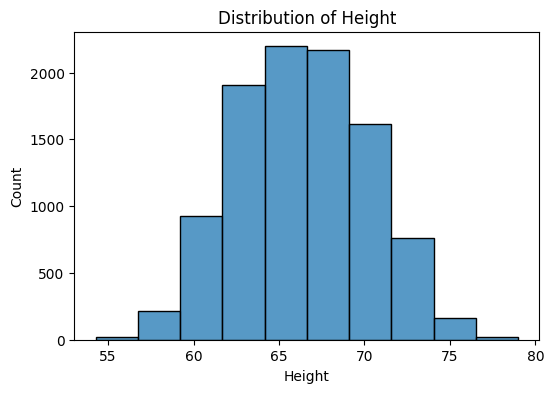

In [ ]:
# histogram plot for Height
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Height', bins=10)
plt.title("Distribution of Height")
plt.show()

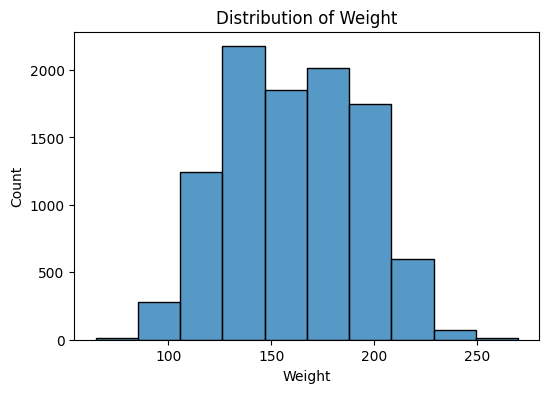

In [ ]:
# histogram plot for Weight
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Weight', bins=10)
plt.title("Distribution of Weight")
plt.show()

In [ ]:
#weight outliers
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Weight'] < lower_bound) | (df['Weight'] > upper_bound)]

print("Weight Outliers (using IQR method):")
display(outliers)

Weight Outliers (using IQR method):


,Gender,Height,Weight
2014,Male,78.998742,269.989699


In [ ]:
#height outliers
Q1_height = df['Height'].quantile(0.25)
Q3_height = df['Height'].quantile(0.75)
IQR_height = Q3_height - Q1_height

lower_bound_height = Q1_height - 1.5 * IQR_height
upper_bound_height = Q3_height + 1.5 * IQR_height

outliers_height = df[(df['Height'] < lower_bound_height) | (df['Height'] > upper_bound_height)]

print("Height Outliers (using IQR method):")
display(outliers_height)

Height Outliers (using IQR method):


,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127


### Replacing Outliers with Median (or Mean)

In [ ]:
# Replace Weight outliers with the median of the non-outlier weights
median_weight = df[~((df['Weight'] < lower_bound) | (df['Weight'] > upper_bound))]['Weight'].median()
# mean_weight = df[~((df['Weight'] < lower_bound) | (df['Weight'] > upper_bound))]['Weight'].mean()

df.loc[(df['Weight'] < lower_bound) | (df['Weight'] > upper_bound), 'Weight'] = median_weight

print("Weight outliers replaced with median. Displaying updated DataFrame head:")
display(df.head())

Weight outliers replaced with median. Displaying updated DataFrame head:


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
# Replace Height outliers with the median of the non-outlier heights
median_height = df[~((df['Height'] < lower_bound_height) | (df['Height'] > upper_bound_height))]['Height'].median()
# mean_height = df[~((df['Height'] < lower_bound_height) | (df['Height'] > upper_bound_height))]['Height'].mean()

df.loc[(df['Height'] < lower_bound_height) | (df['Height'] > upper_bound_height), 'Height'] = median_height

print("Height outliers replaced with median. Displaying updated DataFrame head:")
display(df.head())

Height outliers replaced with median. Displaying updated DataFrame head:


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
